# Práctica 2: Determinación de tipos de estrellas

## 0. Introducción

En esta práctica se aborda un problema de aprendizaje no supervisado aplicado al ámbito de la astronomía. El objetivo es identificar agrupaciones naturales de estrellas a partir de sus características físicas y espectrales, sin disponer de etiquetas previas.

El conjunto de datos contiene 240 estrellas descritas mediante las variables:
- `Temperature`: temperatura superficial media en Kelvin.
- `L`: luminosidad relativa respecto al Sol.
- `R`: radio relativo respecto al Sol.
- `A_M`: magnitud absoluta.
- `Spectral_Class`: clase espectral.
- `Color`: color principal del espectro.

El propósito final de la práctica será comparar distintos algoritmos de clustering y analizar si los grupos encontrados presentan similitudes con las clases estelares utilizadas en astronomía.

## 0.1 Imports necesarios

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

SEED = 100475849
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

En este apartado se importan las librerías necesarias para el análisis exploratorio, la visualización, el preprocesado y los algoritmos de clustering que se utilizarán más adelante. Además, se fija una semilla para asegurar la reproducibilidad de los resultados.

## 1. EDA

### 1.1 Carga del conjunto de datos y primera inspección

El primer paso del análisis exploratorio consiste en cargar el conjunto de datos y examinar su estructura general. Esto permite comprobar el número de observaciones, las variables disponibles y el formato en el que se encuentran almacenadas.

Esta revisión inicial es importante porque ayuda a detectar problemas tempranos, como nombres de columnas inconsistentes, tipos de datos incorrectos o posibles valores anómalos.

In [2]:
df = pd.read_csv("data/stars_data.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())
display(df.sample(5, random_state=SEED))

Dimensiones del dataset: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


,Temperature,L,R,A_M,Color,Spectral_Class
70,3345,0.021000,0.2730,12.30,Red,M
73,3150,0.008800,0.3500,11.94,Red,M
232,32489,648430.000000,1948.5000,-10.84,Blue,O
111,3605,126000.000000,1124.0000,-10.81,Red,M
128,2856,0.000896,0.0782,19.56,Red,M


**Conclusión**: El dataset contiene 240 estrellas y 6 variables, combinando atributos numéricos y categóricos. La carga se ha realizado correctamente y, a simple vista, ya se observan estrellas con características muy diferentes, lo que hace razonable esperar la existencia de varios grupos en los datos.

### 1.2 Estructura de variables y calidad básica de los datos

A continuación se analizan los tipos de datos de cada variable, la presencia de valores nulos y la posible existencia de duplicados. Este paso es fundamental, ya que cualquier problema de calidad de datos puede afectar tanto al preprocesado como al rendimiento de los algoritmos de clustering.

In [3]:
display(df.info())

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nNúmero de duplicados:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


None


Valores nulos por columna:


,nulos
Temperature,0
L,0
R,0
A_M,0
Color,0
Spectral_Class,0



Número de duplicados: 0


**Conclusión**: Podemos observar que no hay valores nulos y del mismo modo tampoco tenemos columnas duplicadas.

### 1.3 Análisis descriptivo de variables numéricas

Se estudian las variables numéricas mediante estadísticos descriptivos como la media, la desviación típica, los cuartiles y los valores extremos. Este análisis permite entender la escala de cada variable y detectar posibles asimetrías o valores atípicos.

Este paso es especialmente relevante en esta práctica porque posteriormente se aplicará PCA y clustering, técnicas sensibles a las diferencias de escala entre variables.

In [4]:
num_cols = ["Temperature", "L", "R", "A_M"]

display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temperature,240.0,10497.462500,9552.425037,1939.00000,3344.250000,5776.0000,15055.5000,40000.00
L,240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
R,240.0,237.157781,517.155763,0.00840,0.102750,0.7625,42.7500,1948.50
A_M,240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06


**Conclusión**: Los estadísticos descriptivos muestran que las variables numéricas presentan escalas muy diferentes entre sí. Además, `L` y `R` parecen estar fuertemente sesgadas, con valores máximos muy alejados de la mediana, lo que sugiere la presencia de estrellas con características extremas. En conjunto, este análisis refuerza la necesidad de estandarizar los datos antes de aplicar PCA y los algoritmos de clustering.

### 1.4 Distribución de las variables numéricas

Una vez revisados los estadísticos descriptivos, se representan gráficamente las distribuciones de las variables numéricas. El objetivo es analizar su forma, detectar asimetrías y observar si existen concentraciones de valores o colas largas.

Este análisis resulta útil para anticipar si algunas variables podrían requerir transformaciones adicionales o una atención especial durante el preprocesado.

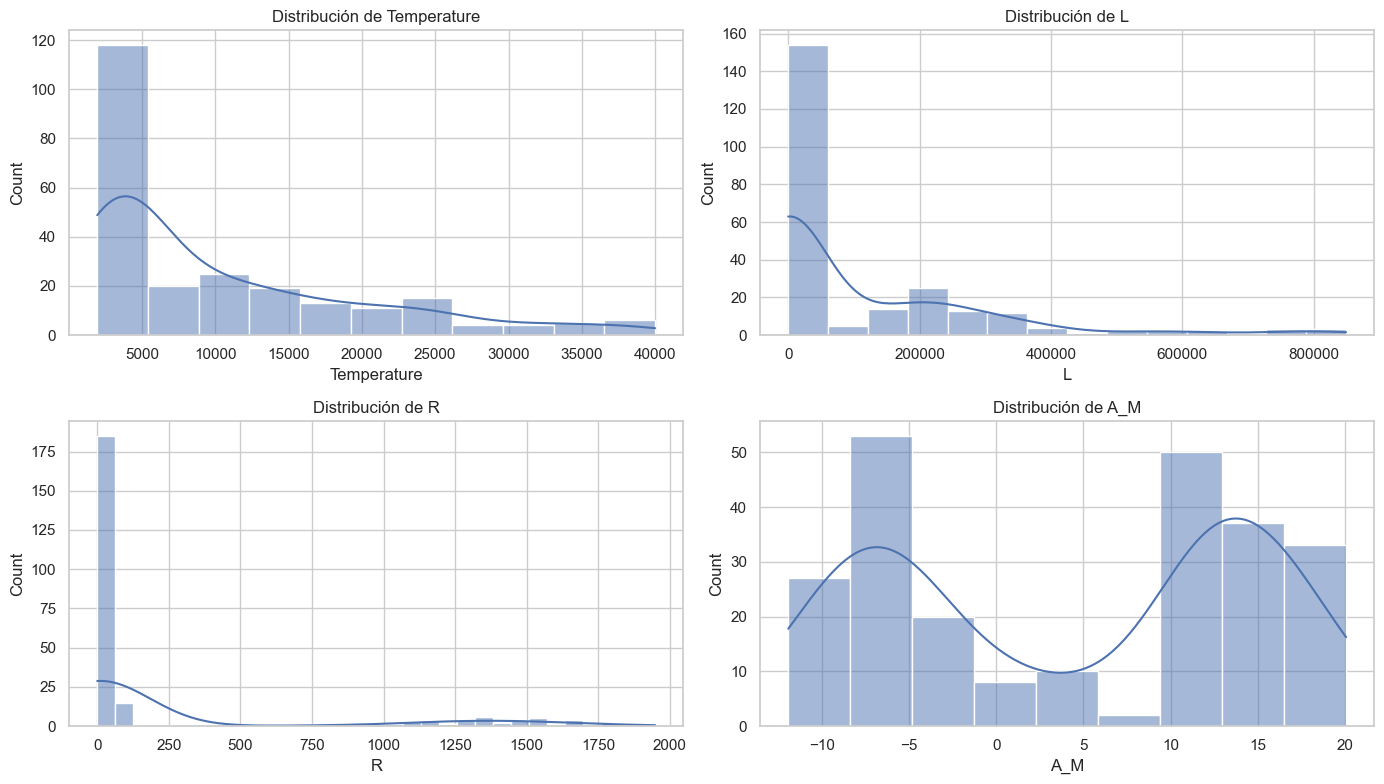

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: Las distribuciones de `Temperature`, `L` y `R` muestran una clara asimetría positiva, con gran concentración de estrellas en valores bajos y una cola larga hacia valores altos. Esto sugiere la existencia de observaciones extremas que podrían influir en el clustering. Por su parte, `A_M` presenta una distribución menos concentrada y parece reflejar varios grupos de estrellas con comportamientos distintos.

## 1.5 Detección visual de valores atípicos

Tras analizar la distribución de las variables numéricas, resulta útil estudiar la posible presencia de valores atípicos mediante diagramas de caja. Este análisis permite identificar observaciones extremas y valorar su impacto potencial en técnicas posteriores como PCA y clustering.

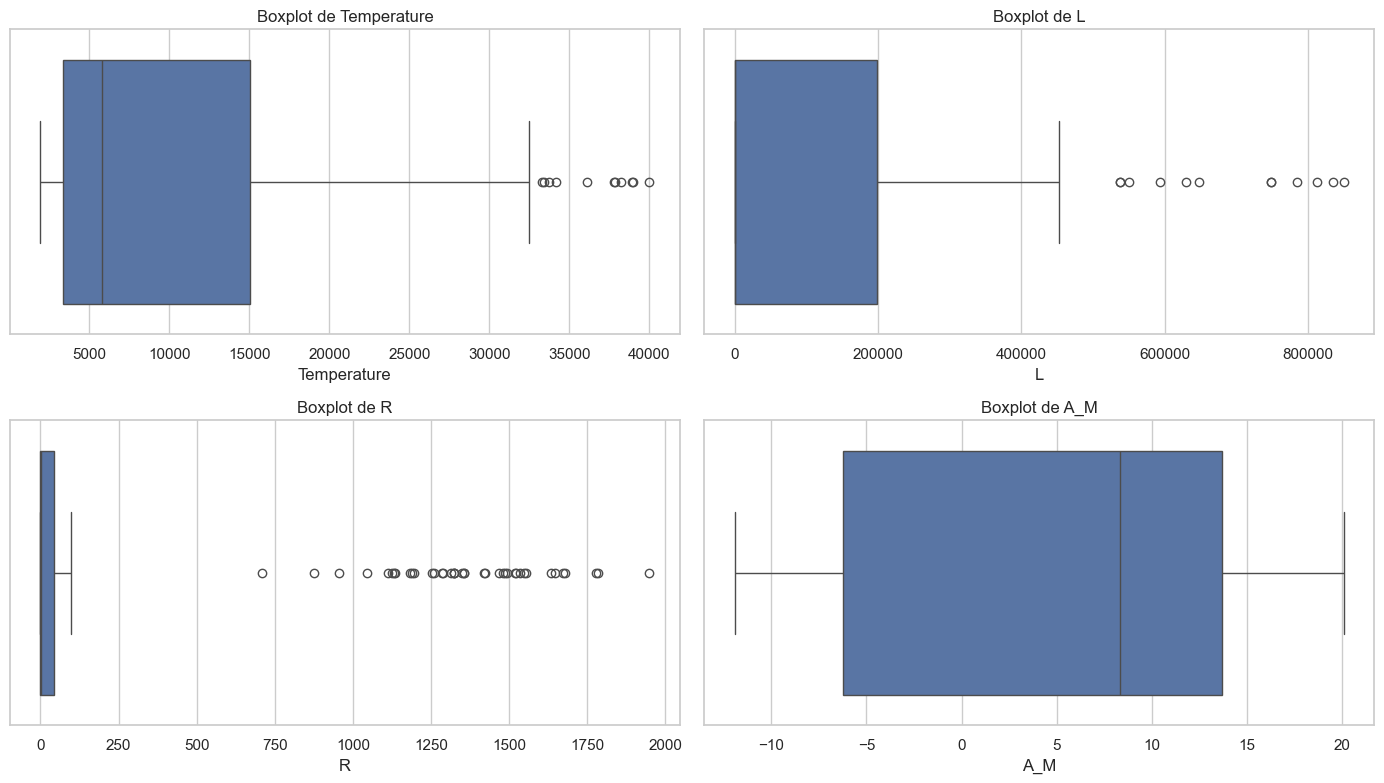

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: Los boxplots muestran la presencia de valores atípicos, especialmente en `L` y `R`, y en menor medida en `Temperature`. Esto indica que existen estrellas con características muy extremas respecto al resto del conjunto. En cambio, `A_M` presenta una distribución más estable. Dado el contexto del problema, estos valores extremos no deben considerarse necesariamente errores, sino posibles observaciones relevantes para la formación de grupos.

## 1.6 Análisis de variables categóricas

En este apartado se estudian las variables categóricas `Color` y `Spectral_Class`. El objetivo es conocer sus valores posibles, su frecuencia y detectar posibles inconsistencias en el etiquetado. Este paso es especialmente importante, ya que ambas variables deberán codificarse posteriormente de forma ordinal, respetando su relación con la energía.

In [7]:
cat_cols = ["Color", "Spectral_Class"]

for col in cat_cols:
    print(f"\nFrecuencias de {col}:")
    display(df[col].value_counts())
    print(f"Valores únicos en {col}: {df[col].nunique()}")


Frecuencias de Color:


Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

Valores únicos en Color: 17

Frecuencias de Spectral_Class:


Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

Valores únicos en Spectral_Class: 7


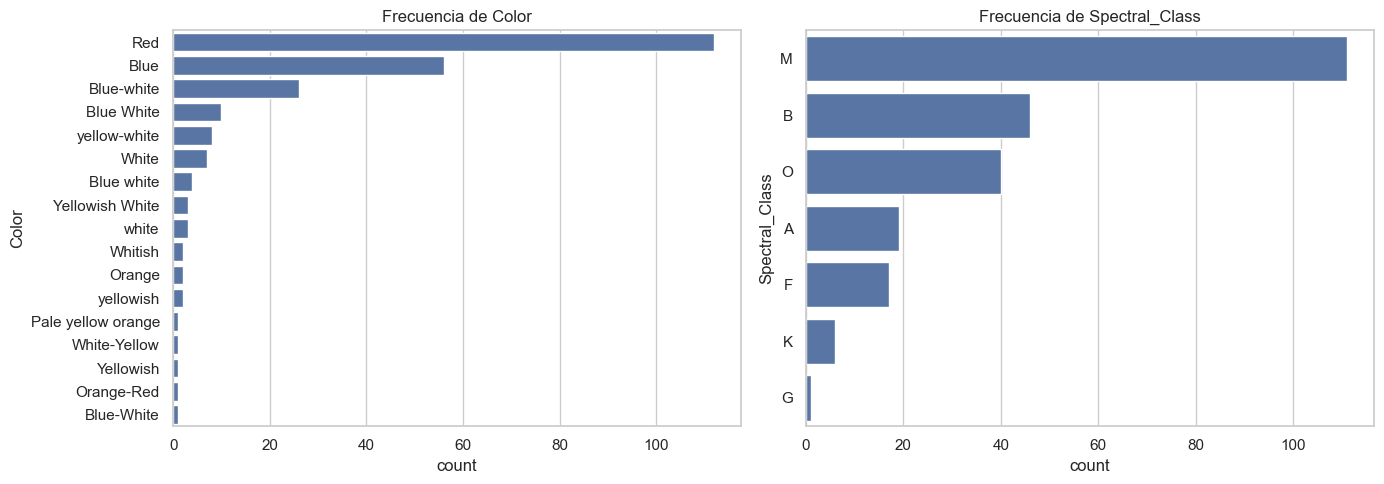

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(f"Frecuencia de {col}")

plt.tight_layout()
plt.show()

**Conclusión**: El análisis de las variables categóricas muestra que `Color` y `Spectral_Class` presentan un número reducido de categorías, aunque con una distribución desigual. En `Color` se observan además varias inconsistencias de escritura, como diferencias entre mayúsculas, espacios y guiones, por lo que será necesario unificar estas etiquetas antes de realizar la codificación ordinal. Por su parte, `Spectral_Class` presenta un claro predominio de algunas clases, especialmente `M`.

## 1.7 Relación entre variables numéricas

Una vez analizadas las distribuciones individuales, resulta útil estudiar la relación entre las variables numéricas mediante una matriz de correlación. Esto permite identificar dependencias lineales entre atributos y valorar si existe información redundante, algo relevante de cara a la aplicación posterior de PCA.

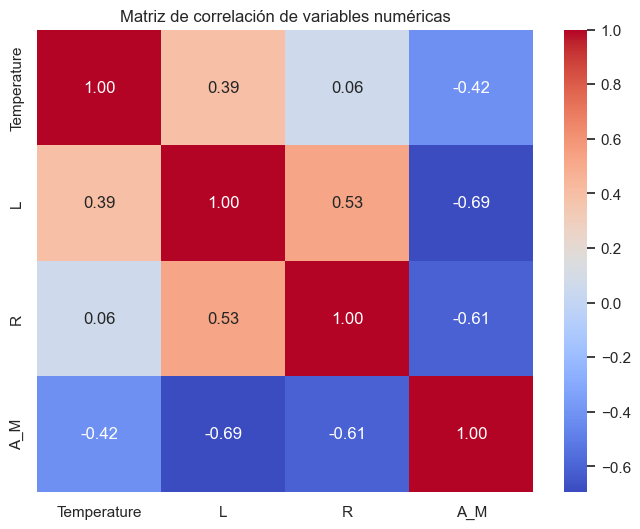

In [9]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

**Conclusión**: La matriz de correlación muestra que existen relaciones relevantes entre varias variables numéricas. En particular, `L` y `R` presentan una correlación positiva moderada, mientras que `A_M` se relaciona de forma negativa con ambas. Esto indica que parte de la información está compartida entre variables, lo que justifica el uso posterior de PCA para reducir dimensionalidad.

## 1.8 Conclusiones del EDA

- El dataset contiene 240 estrellas y 6 variables, sin valores nulos ni duplicados.
- Las variables numéricas presentan escalas muy diferentes, especialmente `L` y `R`.
- En `Temperature`, `L` y `R` se observan distribuciones asimétricas y valores extremos.
- `Color` y `Spectral_Class` son variables categóricas con significado ordinal, ya que están relacionadas con la energía de la estrella.
- En `Color` aparecen varias inconsistencias de escritura, por lo que será necesario unificar etiquetas antes de codificar.
- La correlación entre algunas variables numéricas justifica aplicar PCA para reducir dimensionalidad antes del clustering.
- En conjunto, el EDA confirma que el siguiente paso debe ser el preprocesado: limpieza de categorías, codificación ordinal, estandarización y PCA a 2 componentes.

## 2. Preprocesado de los datos

En este apartado se prepara el dataset para aplicar las técnicas de clustering. Para ello, primero se revisan y limpian las variables categóricas, después se realiza su codificación ordinal y, finalmente, se estandarizan los datos y se aplica PCA a 2 componentes principales.

### 2.1 Revisión de categorías

Antes de codificar las variables categóricas, se revisan sus valores únicos para detectar posibles inconsistencias en el etiquetado. Este paso es especialmente importante en `Color`, donde durante el EDA ya se observaron diferencias en mayúsculas, espacios y guiones.

In [10]:
print("Valores únicos de Color:")
print(sorted(df["Color"].unique()))

print("\nValores únicos de Spectral_Class:")
print(sorted(df["Spectral_Class"].unique()))

Valores únicos de Color:
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Valores únicos de Spectral_Class:
['A', 'B', 'F', 'G', 'K', 'M', 'O']


**Conclusión**: La revisión de valores únicos confirma que `Color` contiene varias etiquetas equivalentes escritas de forma distinta, por lo que será necesario unificarlas antes de la codificación. En cambio, `Spectral_Class` presenta categorías limpias y bien definidas.

### 2.2 Limpieza de la variable `Color`

Se unifican las distintas formas de escribir una misma categoría en la variable `Color`. De este modo, se evitan duplicidades artificiales y se asegura una codificación ordinal coherente.

In [11]:
df_clean = df.copy()

color_mapping = {
    "Red": "Red",
    "Orange-Red": "Orange-Red",
    "Orange": "Orange",
    "Pale yellow orange": "Pale Yellow Orange",
    "yellowish": "Yellowish",
    "Yellowish": "Yellowish",
    "yellow-white": "Yellow-White",
    "White-Yellow": "Yellow-White",
    "White": "White",
    "white": "White",
    "Whitish": "Whitish",
    "Yellowish White": "Yellowish White",
    "Blue-white": "Blue-White",
    "Blue white": "Blue-White",
    "Blue White": "Blue-White",
    "Blue-White": "Blue-White",
    "Blue": "Blue"
}

df_clean["Color"] = df_clean["Color"].str.strip().replace(color_mapping)

print("Valores únicos de Color tras la limpieza:")
print(sorted(df_clean["Color"].unique()))

Valores únicos de Color tras la limpieza:
['Blue', 'Blue-White', 'Orange', 'Orange-Red', 'Pale Yellow Orange', 'Red', 'White', 'Whitish', 'Yellow-White', 'Yellowish', 'Yellowish White']


**Conclusión**: Tras la limpieza, la variable `Color` queda formada por un conjunto de categorías más consistente y sin duplicidades debidas a diferencias de escritura. Esto permitirá aplicar una codificación ordinal más fiable.